In [14]:
!pip -q install kagglehub scikit-learn seaborn matplotlib pandas numpy tensorflow

import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MAX_WORDS = 10000
MAX_LEN = 50
BATCH_SIZE = 64
EPOCHS = 5
EMBEDDING_DIM = 64

print(f"TensorFlow version: {tf.__version__}")
print(f"Project initialized at: {PROJECT_ROOT}")

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

TensorFlow version: 2.20.0
Project initialized at: /content


In [15]:
path = kagglehub.dataset_download("crowdflower/twitter-airline-sentiment")
dataset_root = Path(path)

csv_file = next(dataset_root.glob("*.csv"))
df = pd.read_csv(csv_file)

df = df[['text', 'airline_sentiment']]
df = df[df['airline_sentiment'] != 'neutral'].reset_index(drop=True)
df['label'] = df['airline_sentiment'].map({'positive': 1, 'negative': 0})

print(f"Cleaned dataset size: {df.shape[0]} rows")
display(df.head())

Using Colab cache for faster access to the 'twitter-airline-sentiment' dataset.
Cleaned dataset size: 11541 rows


,text,airline_sentiment,label
0,@VirginAmerica plus you've added commercials t...,positive,1
1,@VirginAmerica it's really aggressive to blast...,negative,0
2,@VirginAmerica and it's a really big bad thing...,negative,0
3,@VirginAmerica seriously would pay $30 a fligh...,negative,0
4,"@VirginAmerica yes, nearly every time I fly VX...",positive,1


/tmp/ipykernel_6667/1121585628.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_counts, x='Sentiment', y='Count', ax=axes[0], palette='viridis')


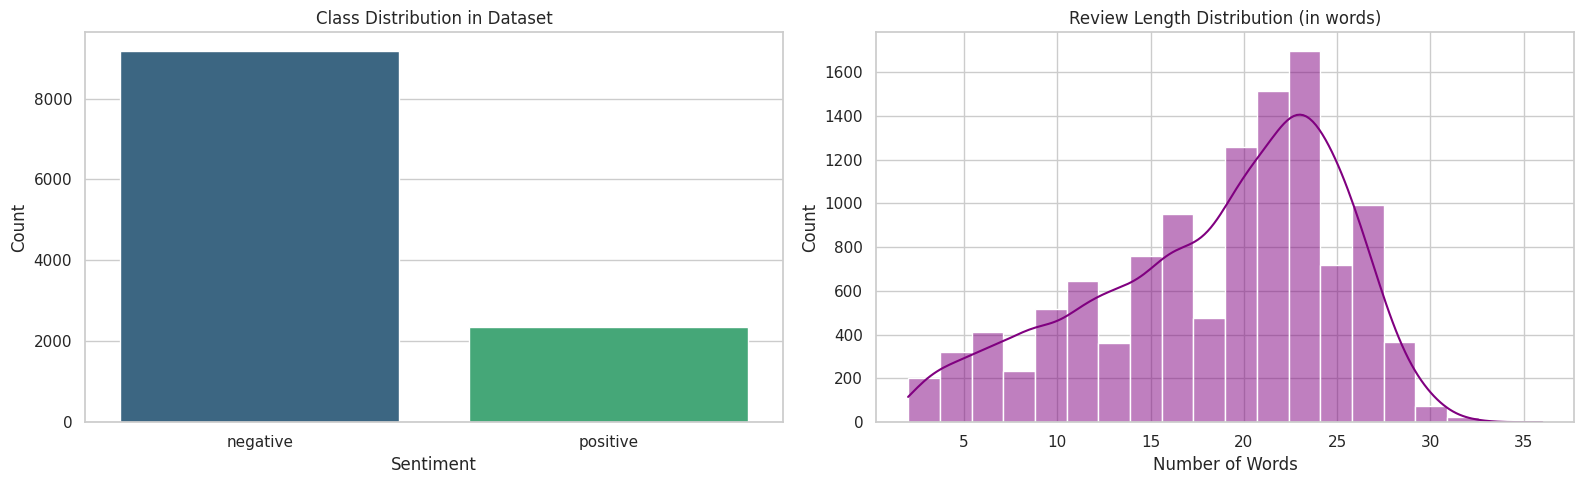

In [16]:
sentiment_counts = df['airline_sentiment'].value_counts().reset_index()
sentiment_counts.columns = ['Sentiment', 'Count']

df['text_length'] = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=sentiment_counts, x='Sentiment', y='Count', ax=axes[0], palette='viridis')
axes[0].set_title('Class Distribution in Dataset')

sns.histplot(df['text_length'], bins=20, ax=axes[1], kde=True, color='purple')
axes[1].set_title('Review Length Distribution (in words)')
axes[1].set_xlabel('Number of Words')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_text_metrics.png', dpi=150)
plt.show()

In [17]:
texts = df['text'].values
labels = df['label'].values

X_train_raw, X_temp, y_train, y_temp = train_test_split(texts, labels, test_size=0.30, random_state=SEED, stratify=labels)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_WORDS,
    output_mode='int',
    output_sequence_length=MAX_LEN
)

vectorize_layer.adapt(X_train_raw)

X_train = vectorize_layer(X_train_raw)
X_val = vectorize_layer(X_val_raw)
X_test = vectorize_layer(X_test_raw)

print(f"Training tensor shape: {X_train.shape}")
print(f"Vocabulary size: {len(vectorize_layer.get_vocabulary())}")

Training tensor shape: (8078, 50)
Vocabulary size: 10000


In [18]:
def build_baseline_mlp():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(MAX_LEN,)),
        tf.keras.layers.Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ], name="Baseline_MLP")

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_simple_rnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(MAX_LEN,)),
        tf.keras.layers.Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM),
        tf.keras.layers.SimpleRNN(32),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ], name="Simple_RNN")

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_lstm_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(MAX_LEN,)),
        tf.keras.layers.Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM),
        tf.keras.layers.LSTM(32, dropout=0.2, recurrent_dropout=0.2),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ], name="LSTM_Network")

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def train_nlp_model(model, X_tr, y_tr, X_v, y_v, model_name):
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(MODELS_DIR / f"{model_name}.keras"),
            monitor='val_loss',
            save_best_only=True
        )
    ]
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    return history

In [19]:
print("\n=== Training Model 1: Baseline MLP ===")
mlp_model = build_baseline_mlp()
mlp_history = train_nlp_model(mlp_model, X_train, y_train, X_val, y_val, "nlp_baseline_mlp")

print("\n=== Training Model 2: Simple RNN ===")
rnn_model = build_simple_rnn()
rnn_history = train_nlp_model(rnn_model, X_train, y_train, X_val, y_val, "nlp_simple_rnn")

print("\n=== Training Model 3: LSTM Network ===")
lstm_model = build_lstm_model()
lstm_history = train_nlp_model(lstm_model, X_train, y_train, X_val, y_val, "nlp_lstm")

print("\nAll models trained successfully!")


=== Training Model 1: Baseline MLP ===
Epoch 1/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7948 - loss: 0.5316 - val_accuracy: 0.7955 - val_loss: 0.4909
Epoch 2/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8115 - loss: 0.4136 - val_accuracy: 0.8550 - val_loss: 0.3469
Epoch 3/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8773 - loss: 0.2993 - val_accuracy: 0.8873 - val_loss: 0.2788
Epoch 4/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9115 - loss: 0.2284 - val_accuracy: 0.9012 - val_loss: 0.2370
Epoch 5/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9345 - loss: 0.1800 - val_accuracy: 0.9070 - val_loss: 0.2172

=== Training Model 2: Simple RNN ===
Epoch 1/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7935 - loss: 0.5119 - val_accuracy: 0.7955 - val_loss: 0.5068
Epoch 2/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7952 - loss: 0.5073 - val_accuracy: 0.7955 - val_loss: 0.5068
Epoch 3/5
127/127 ━━━━━━━━━━━━

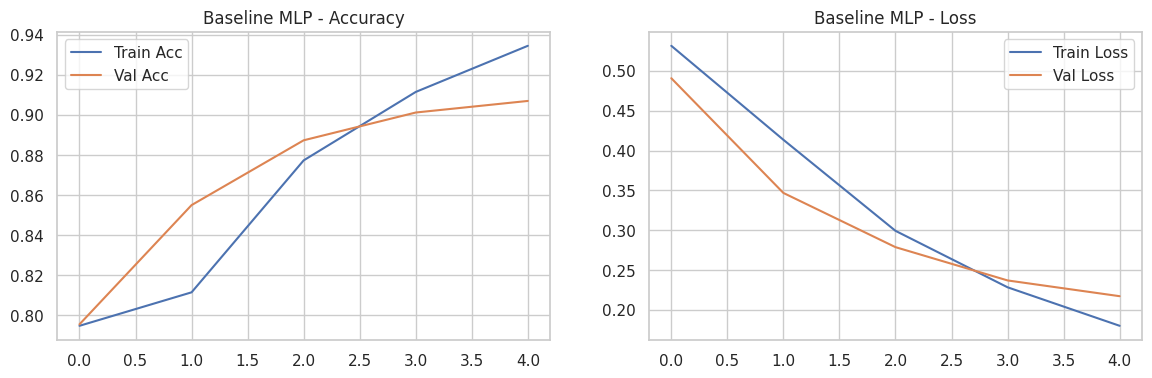

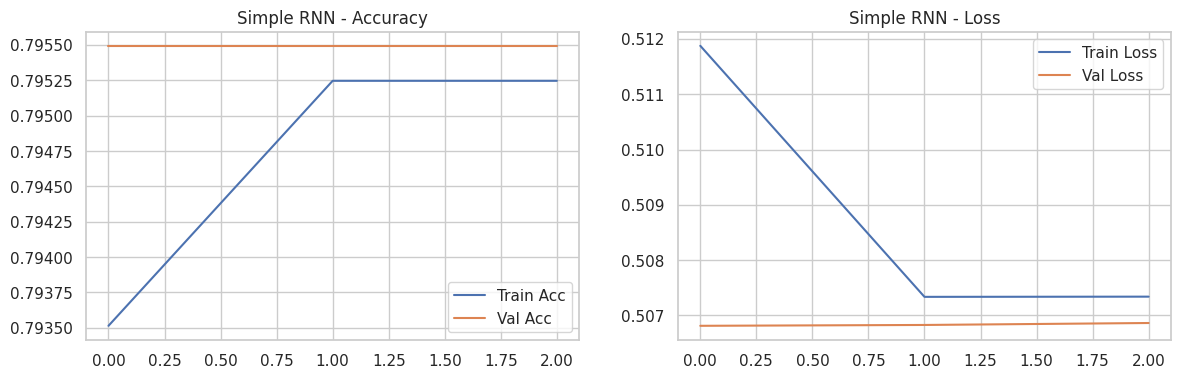

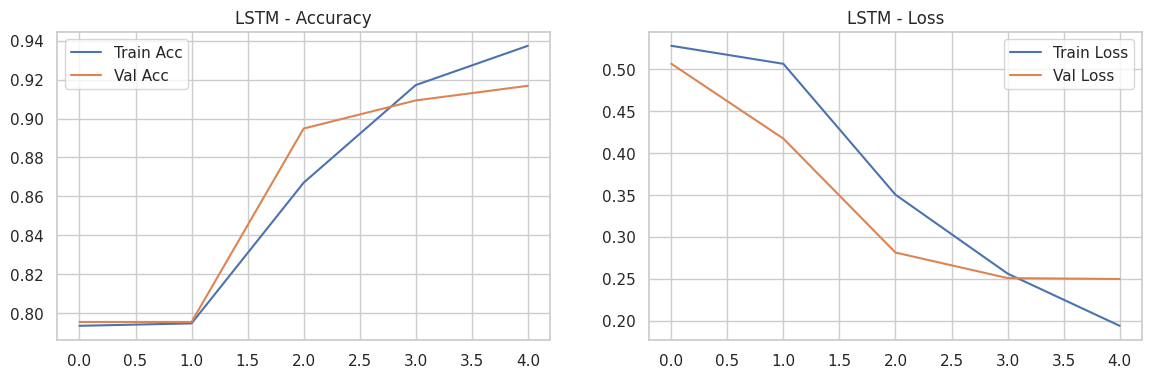

In [20]:
def plot_learning_curves(history, title, filename):
    hist = history.history
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(hist['accuracy'], label='Train Acc')
    axes[0].plot(hist['val_accuracy'], label='Val Acc')
    axes[0].set_title(f'{title} - Accuracy')
    axes[0].legend()

    axes[1].plot(hist['loss'], label='Train Loss')
    axes[1].plot(hist['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} - Loss')
    axes[1].legend()
    plt.savefig(RESULTS_DIR / filename, dpi=150)
    plt.show()

def calculate_metrics(model, X_te, y_te):
    preds = model.predict(X_te, verbose=0).flatten()
    y_pred = (preds >= 0.5).astype(int)

    acc = accuracy_score(y_te, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_te, y_pred, average='binary')
    cm = confusion_matrix(y_te, y_pred)
    return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'cm': cm, 'y_pred': y_pred}

plot_learning_curves(mlp_history, "Baseline MLP", "mlp_curves.png")
plot_learning_curves(rnn_history, "Simple RNN", "rnn_curves.png")
plot_learning_curves(lstm_history, "LSTM", "lstm_curves.png")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


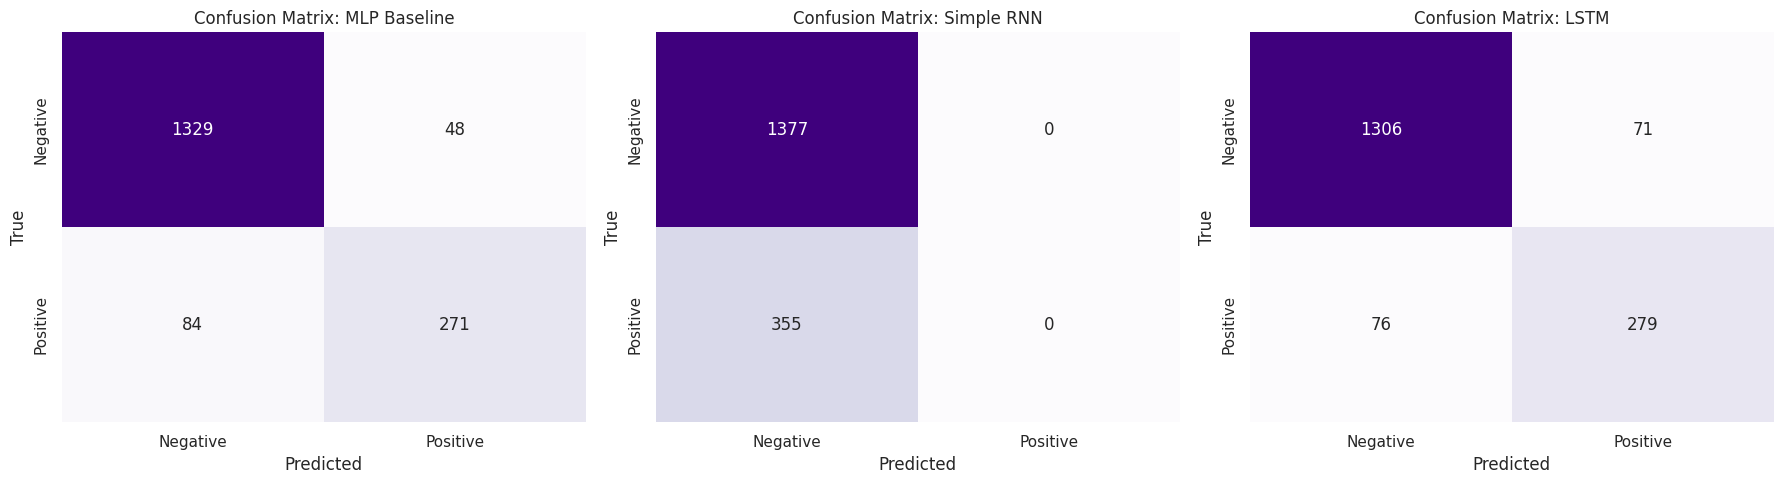

In [21]:
mlp_results = calculate_metrics(mlp_model, X_test, y_test)
rnn_results = calculate_metrics(rnn_model, X_test, y_test)
lstm_results = calculate_metrics(lstm_model, X_test, y_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['Negative', 'Positive']

for ax, res, title in zip(axes, [mlp_results, rnn_results, lstm_results], ['MLP Baseline', 'Simple RNN', 'LSTM']):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Purples', ax=ax, cbar=False,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(f'Confusion Matrix: {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_comparison.png', dpi=150)
plt.show()

In [22]:
comparison_df = pd.DataFrame([
    {'Model': 'Baseline MLP', 'Accuracy': mlp_results['acc'], 'Precision': mlp_results['prec'], 'Recall': mlp_results['rec'], 'F1-Score': mlp_results['f1']},
    {'Model': 'Simple RNN', 'Accuracy': rnn_results['acc'], 'Precision': rnn_results['prec'], 'Recall': rnn_results['rec'], 'F1-Score': rnn_results['f1']},
    {'Model': 'LSTM Network', 'Accuracy': lstm_results['acc'], 'Precision': lstm_results['prec'], 'Recall': lstm_results['rec'], 'F1-Score': lstm_results['f1']}
])

print("\n=== Final Model Comparison (Test Set) ===")
display(comparison_df.sort_values('Accuracy', ascending=False))
comparison_df.to_csv(RESULTS_DIR / 'nlp_model_comparison.csv', index=False)

best_model_row = comparison_df.sort_values('Accuracy', ascending=False).iloc[0]
best_name = best_model_row['Model']
print(f"\nWinner by Accuracy metric: {best_name}")

if best_name == 'Baseline MLP':
    best_model, best_eval = mlp_model, mlp_results
elif best_name == 'Simple RNN':
    best_model, best_eval = rnn_model, rnn_results
else:
    best_model, best_eval = lstm_model, lstm_results

best_model.save(MODELS_DIR / 'best_nlp_model.keras')


=== Final Model Comparison (Test Set) ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline MLP,0.923788,0.849530,0.763380,0.804154
2,LSTM Network,0.915127,0.797143,0.785915,0.791489
1,Simple RNN,0.795035,0.000000,0.000000,0.000000



Winner by Accuracy metric: Baseline MLP


In [23]:
y_pred_best = best_eval['y_pred']
error_indices = np.where(y_test != y_pred_best)[0]

print(f"Number of errors of the best model on test set: {len(error_indices)} out of {len(y_test)}")
print("\n=== Top 5 Text Examples Where the Model Erred ===")

for i in error_indices[:5]:
    true_label_str = "Positive" if y_test[i] == 1 else "Negative"
    pred_label_str = "Positive" if y_pred_best[i] == 1 else "Negative"
    print(f"Review Text: {X_test_raw[i]}")
    print(f"True Class: {true_label_str} | Predicted Class: {pred_label_str}")
    print("-" * 80)

Number of errors of the best model on test set: 132 out of 1732

=== Top 5 Text Examples Where the Model Erred ===
Review Text: @USAirways @AmericanAir shout out to Diane at EYW for helping get us home today instead of tomorrow (even if a little Late Flight!)
True Class: Positive | Predicted Class: Negative
--------------------------------------------------------------------------------
Review Text: @SouthwestAir I got a flight at 11:55am on Thursday but looking for something tomorrow, anything available?
True Class: Positive | Predicted Class: Negative
--------------------------------------------------------------------------------
Review Text: @AmericanAir thank you! My lost item was located at ORD and is being returned to me.
True Class: Positive | Predicted Class: Negative
--------------------------------------------------------------------------------
Review Text: @united thank you. Been trying for two days to set this up.
True Class: Positive | Predicted Class: Negative
---------